In [7]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

from skimage.feature import hog, local_binary_pattern
from xgboost import XGBClassifier


In [9]:
# -------------------------
# CONFIG
# -------------------------
IMG_SIZE = 224
DATASET_PATH = "D:/cuchia"  # change this

In [11]:
# -------------------------
# LOAD DATA
# -------------------------
def load_images(folder, label):
    images, labels = [], []
    
    for file in os.listdir(folder):
        path = os.path.join(folder, file)
        img = cv2.imread(path)
        if img is None:
            continue
        
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0
        
        images.append(img)
        labels.append(label)
    
    return images, labels


normal_images, normal_labels = load_images(os.path.join(DATASET_PATH, "normal"), 0)
acid_images, acid_labels = load_images(os.path.join(DATASET_PATH, "acid"), 1)

X = np.array(normal_images + acid_images)
y = np.array(normal_labels + acid_labels)

print("Total images:", len(X))

Total images: 334


In [12]:
# -------------------------
# AUGMENTATION (6x)
# -------------------------
def augment_image(img):
    augmented = []

    # Rotation
    for angle in [90, 180, 270]:
        M = cv2.getRotationMatrix2D((IMG_SIZE//2, IMG_SIZE//2), angle, 1)
        augmented.append(cv2.warpAffine(img, M, (IMG_SIZE, IMG_SIZE)))

    # Flip
    augmented.append(cv2.flip(img, 1)) # horizontal
    augmented.append(cv2.flip(img, 0)) # vertical

    # Brightness
    hsv = cv2.cvtColor((img*255).astype(np.uint8), cv2.COLOR_BGR2HSV)
    hsv[:,:,2] = cv2.add(hsv[:,:,2], 30)
    bright = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)
    augmented.append(bright/255.0)

    return augmented


augmented_images, augmented_labels = [], []

for i in range(len(X)):
    aug = augment_image(X[i])
    augmented_images.extend(aug)
    augmented_labels.extend([y[i]] * len(aug))

X = np.concatenate((X, np.array(augmented_images)))
y = np.concatenate((y, np.array(augmented_labels)))

print("After augmentation:", len(X))


After augmentation: 2338


In [17]:
# -------------------------
# SEGMENTATION (FIXED)
# -------------------------
# Segmentation removes unnecessary background
def segment_image(img):
    gray = cv2.cvtColor((img*255).astype(np.uint8), cv2.COLOR_BGR2GRAY)   # Convert to grayscale
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)  #Automatically separates foreground & background
    segmented = cv2.bitwise_and(gray, gray, mask=thresh)   #Keeps only important region
    return segmented / 255.0

In [19]:
# -------------------------
# FEATURE EXTRACTION
# -------------------------

# HOG
# Detects edges and shapes
def extract_hog_features(images):
    features = []
    for img in images:
        gray = cv2.cvtColor((img*255).astype(np.uint8), cv2.COLOR_BGR2GRAY)
        feat = hog(gray, orientations=9, pixels_per_cell=(8,8),
                   cells_per_block=(2,2), block_norm='L2-Hys')
        features.append(feat)
    return np.array(features)

# LBP
# Captures texture patterns - like rough vs smooth
def extract_lbp_features(images):
    features = []
    for img in images:
        gray = cv2.cvtColor((img*255).astype(np.uint8), cv2.COLOR_BGR2GRAY)
        lbp = local_binary_pattern(gray, P=8, R=1, method="uniform")
        hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, 11), range=(0, 10))
        hist = hist.astype("float")
        hist /= (hist.sum() + 1e-6)
        features.append(hist)
    return np.array(features)


# SEGMENTATION FEATURES 
# summarize important region using histogram
def extract_segmentation_features(images):
    features = []
    for img in images:
        seg = segment_image(img)
        hist, _ = np.histogram(seg.ravel(), bins=16, range=(0,1))
        hist = hist.astype("float")
        hist /= (hist.sum() + 1e-6)
        features.append(hist)
    return np.array(features)

# COLOR

def extract_color_features(images):
    features = []
    for img in images:
        img_uint = (img*255).astype(np.uint8)

        mean = np.mean(img_uint, axis=(0,1))    # average color
        std = np.std(img_uint, axis=(0,1))      # variation

        hsv = cv2.cvtColor(img_uint, cv2.COLOR_BGR2HSV)     # better color understanding
        hsv_mean = np.mean(hsv, axis=(0,1))

        features.append(np.concatenate([mean, std, hsv_mean]))
    
    return np.array(features)

In [23]:
# -------------------------
# TRAINING FUNCTIONS
# -------------------------

def train_models(features, labels, feature_name):

    print(f"\n===== {feature_name} =====")

    X_train, X_test, y_train, y_test = train_test_split(
        features, labels, test_size=0.2, stratify=labels, random_state=42) 

    # Scaling
    scaler = StandardScaler()  # Bring all features to same scale
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Class weights
    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y_train),
        y=y_train)
    weight_dict = {0: class_weights[0], 1: class_weights[1]}

    # ---------------- SVM ----------------
    svm = SVC(kernel='rbf', class_weight=weight_dict) # Finds best boundary between classes;; RBF = nonlinear decision boundary
    svm.fit(X_train, y_train)

    y_pred_svm = svm.predict(X_test)

    print("\n--- SVM ---")
    print("Accuracy:", accuracy_score(y_test, y_pred_svm))
    print(confusion_matrix(y_test, y_pred_svm))
    print(classification_report(y_test, y_pred_svm))

    # ---------------- XGBOOST ----------------
    scale_pos_weight = np.sum(y_train == 0) / np.sum(y_train == 1)

    xgb = XGBClassifier(
        n_estimators=300, # Number of trees
        max_depth=5, # Controls how deep the decision tree goes
        learning_rate=0.05, # How fast the model learns
        subsample=0.8, # Uses only 80% of data per tree
        colsample_bytree=0.8, # Uses only 80% of features soo, each tree use different features
        scale_pos_weight=scale_pos_weight, # Handles class imbalance
        use_label_encoder=False, 
        eval_metric='logloss', # Measures model performance
        random_state=42
    )

    xgb.fit(X_train, y_train)

    y_pred_xgb = xgb.predict(X_test)

    print("\n--- XGBoost ---")
    print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
    print(confusion_matrix(y_test, y_pred_xgb))
    print(classification_report(y_test, y_pred_xgb))

    # Confusion matrix plot
    plt.figure()
    sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt="d")
    plt.title(f"Confusion Matrix - XGBoost ({feature_name})")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()



===== HOG =====

--- SVM ---
Accuracy: 0.8247863247863247
[[259  11]
 [ 71 127]]
              precision    recall  f1-score   support

           0       0.78      0.96      0.86       270
           1       0.92      0.64      0.76       198

    accuracy                           0.82       468
   macro avg       0.85      0.80      0.81       468
weighted avg       0.84      0.82      0.82       468



C:\Users\NEURO TECH\.conda\envs\tf\lib\site-packages\xgboost\core.py:158: UserWarning: [11:57:15] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



--- XGBoost ---
Accuracy: 0.8055555555555556
[[253  17]
 [ 74 124]]
              precision    recall  f1-score   support

           0       0.77      0.94      0.85       270
           1       0.88      0.63      0.73       198

    accuracy                           0.81       468
   macro avg       0.83      0.78      0.79       468
weighted avg       0.82      0.81      0.80       468



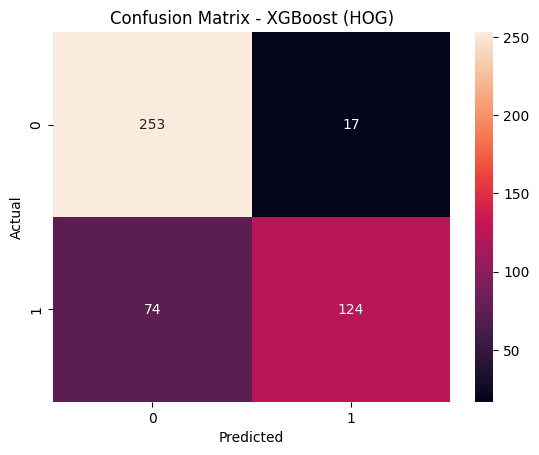


===== LBP =====

--- SVM ---
Accuracy: 0.8568376068376068
[[234  36]
 [ 31 167]]
              precision    recall  f1-score   support

           0       0.88      0.87      0.87       270
           1       0.82      0.84      0.83       198

    accuracy                           0.86       468
   macro avg       0.85      0.86      0.85       468
weighted avg       0.86      0.86      0.86       468



C:\Users\NEURO TECH\.conda\envs\tf\lib\site-packages\xgboost\core.py:158: UserWarning: [12:04:17] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



--- XGBoost ---
Accuracy: 0.9636752136752137
[[266   4]
 [ 13 185]]
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       270
           1       0.98      0.93      0.96       198

    accuracy                           0.96       468
   macro avg       0.97      0.96      0.96       468
weighted avg       0.96      0.96      0.96       468



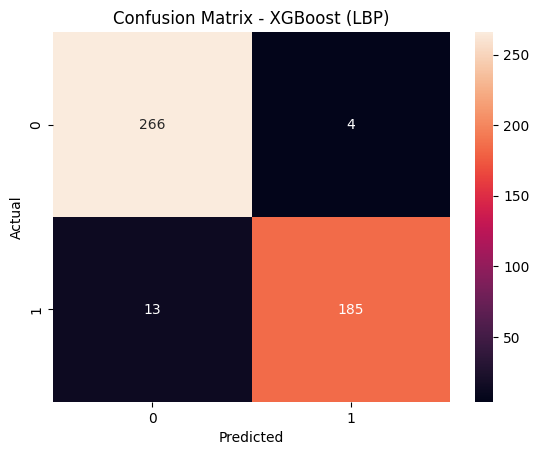


===== Color =====

--- SVM ---
Accuracy: 0.8803418803418803
[[227  43]
 [ 13 185]]
              precision    recall  f1-score   support

           0       0.95      0.84      0.89       270
           1       0.81      0.93      0.87       198

    accuracy                           0.88       468
   macro avg       0.88      0.89      0.88       468
weighted avg       0.89      0.88      0.88       468



C:\Users\NEURO TECH\.conda\envs\tf\lib\site-packages\xgboost\core.py:158: UserWarning: [12:04:26] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



--- XGBoost ---
Accuracy: 0.9594017094017094
[[257  13]
 [  6 192]]
              precision    recall  f1-score   support

           0       0.98      0.95      0.96       270
           1       0.94      0.97      0.95       198

    accuracy                           0.96       468
   macro avg       0.96      0.96      0.96       468
weighted avg       0.96      0.96      0.96       468



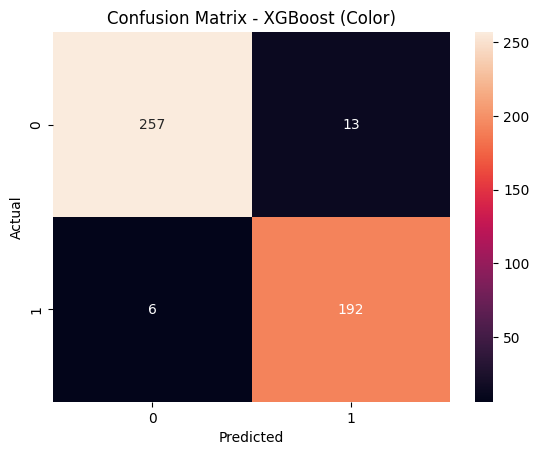


===== Segmentation =====

--- SVM ---
Accuracy: 0.7713675213675214
[[217  53]
 [ 54 144]]
              precision    recall  f1-score   support

           0       0.80      0.80      0.80       270
           1       0.73      0.73      0.73       198

    accuracy                           0.77       468
   macro avg       0.77      0.77      0.77       468
weighted avg       0.77      0.77      0.77       468



C:\Users\NEURO TECH\.conda\envs\tf\lib\site-packages\xgboost\core.py:158: UserWarning: [12:04:29] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



--- XGBoost ---
Accuracy: 0.9294871794871795
[[250  20]
 [ 13 185]]
              precision    recall  f1-score   support

           0       0.95      0.93      0.94       270
           1       0.90      0.93      0.92       198

    accuracy                           0.93       468
   macro avg       0.93      0.93      0.93       468
weighted avg       0.93      0.93      0.93       468



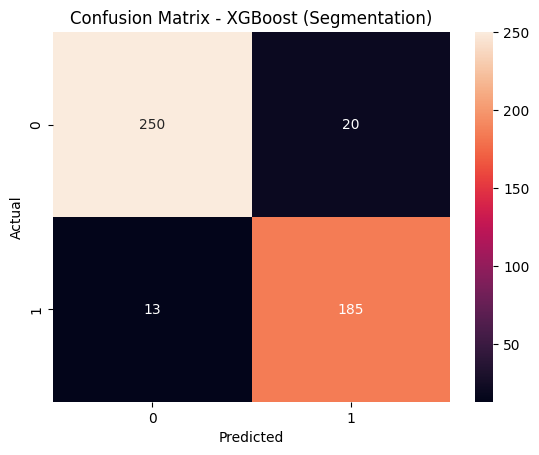

In [25]:
# -------------------------
# RUN FOR ALL FEATURES
# -------------------------

hog_features = extract_hog_features(X)
train_models(hog_features, y, "HOG")

lbp_features = extract_lbp_features(X)
train_models(lbp_features, y, "LBP")

color_features = extract_color_features(X)
train_models(color_features, y, "Color")

seg_features = extract_segmentation_features(X)
train_models(seg_features, y, "Segmentation")

In [26]:
## Data Augmentation and Features presentation

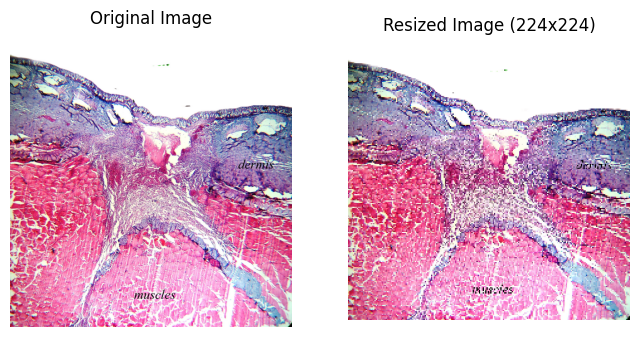

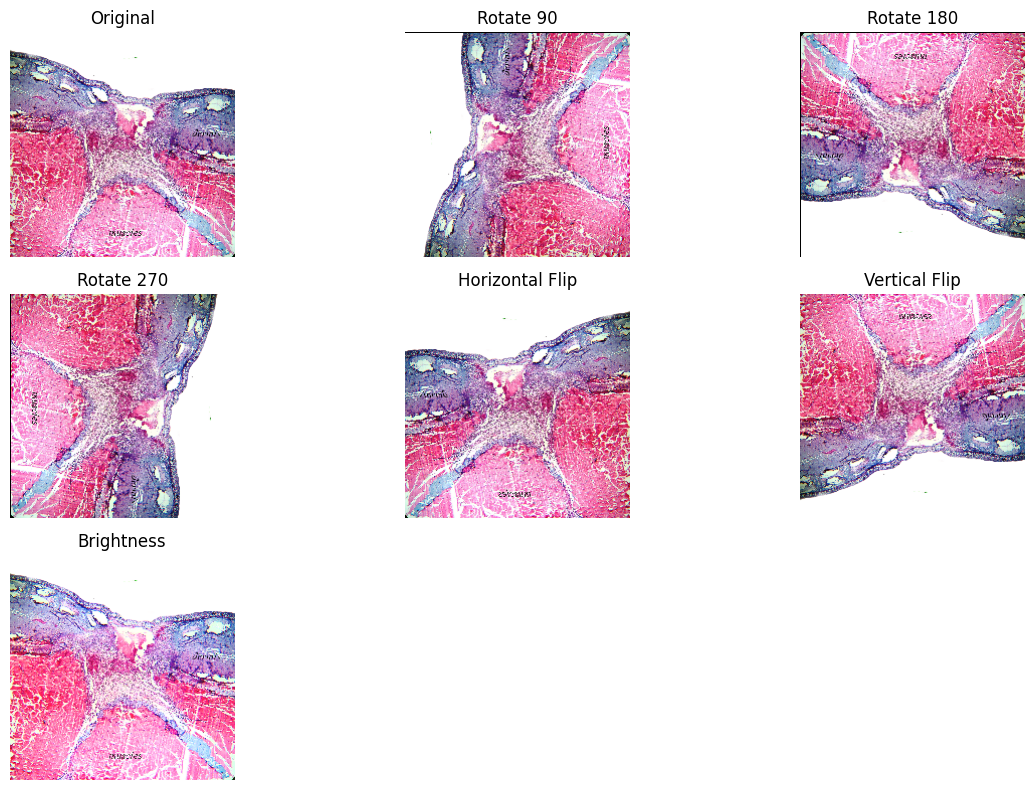

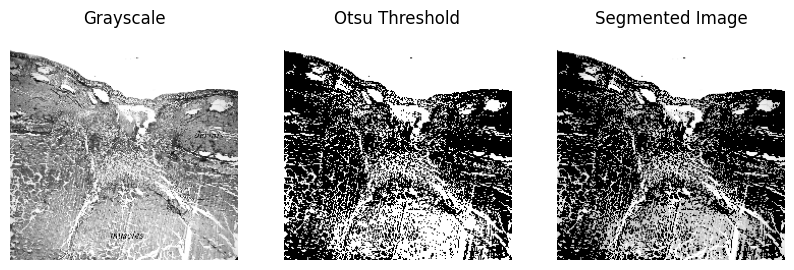

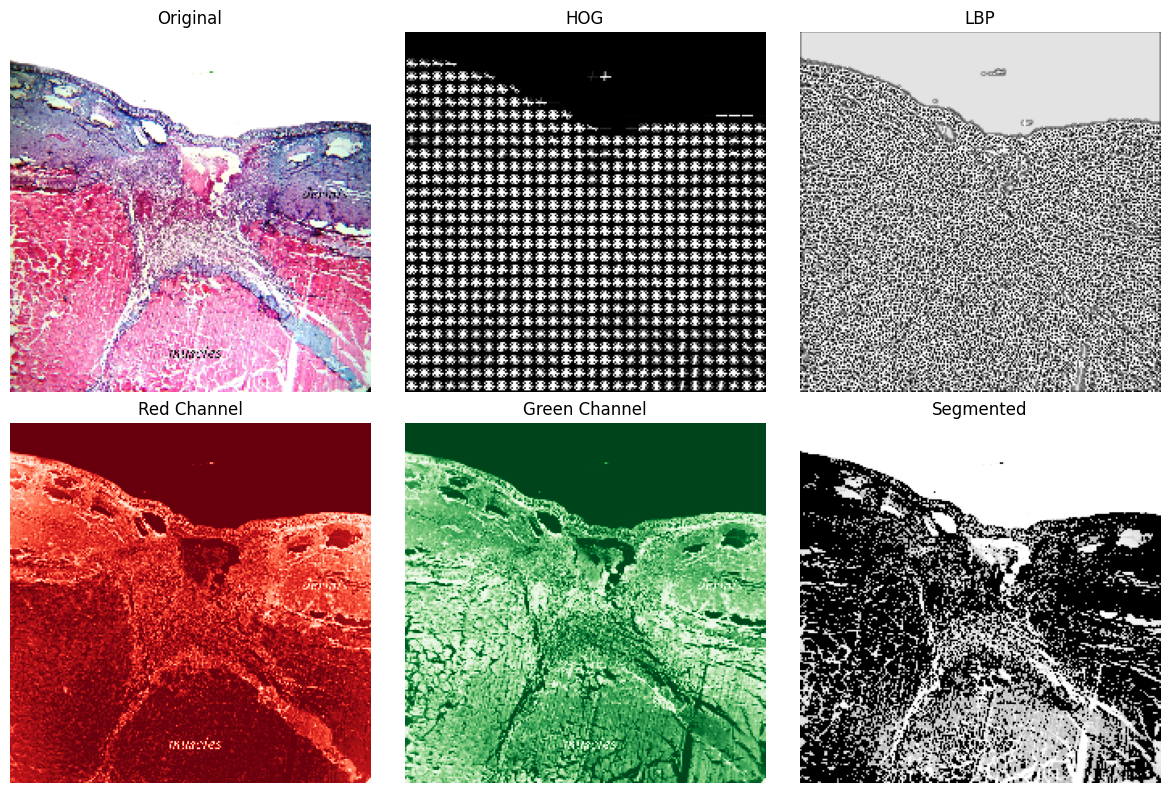

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog, local_binary_pattern
from skimage import exposure

IMG_SIZE = 224

# -------------------------
# LOAD IMAGE
# -------------------------

folder = "D:/cuchia/normal"

files = os.listdir(folder)
image_path = os.path.join(folder, files[0])  # automatically pick first image

img = cv2.imread(image_path)

if img is None:
    print("Error loading image")
    exit()

img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# -------------------------
# 1. RESIZING
# -------------------------
resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(img)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Resized Image (224x224)")
plt.imshow(resized)
plt.axis("off")

plt.show()

# -------------------------
# 2. AUGMENTATION (ALL TYPES)
# -------------------------
def augment_demo(img):
    aug_list = []

    # Rotations
    for angle in [90, 180, 270]:
        M = cv2.getRotationMatrix2D((IMG_SIZE//2, IMG_SIZE//2), angle, 1)
        aug_list.append(("Rotate " + str(angle), cv2.warpAffine(img, M, (IMG_SIZE, IMG_SIZE))))

    # Flip
    aug_list.append(("Horizontal Flip", cv2.flip(img, 1)))
    aug_list.append(("Vertical Flip", cv2.flip(img, 0)))

    # Brightness
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    hsv[:,:,2] = cv2.add(hsv[:,:,2], 40)
    bright = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)
    aug_list.append(("Brightness", bright))

    return aug_list

augmented = augment_demo(resized)

plt.figure(figsize=(12,8))
plt.subplot(3,3,1)
plt.title("Original")
plt.imshow(resized)
plt.axis("off")

for i, (name, aug) in enumerate(augmented):
    plt.subplot(3,3,i+2)
    plt.title(name)
    plt.imshow(aug)
    plt.axis("off")

plt.tight_layout()
plt.show()

# -------------------------
# 3. SEGMENTATION
# -------------------------
gray = cv2.cvtColor(resized, cv2.COLOR_RGB2GRAY)
_, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
segmented = cv2.bitwise_and(gray, gray, mask=thresh)

plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.title("Grayscale")
plt.imshow(gray, cmap='gray')
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Otsu Threshold")
plt.imshow(thresh, cmap='gray')
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Segmented Image")
plt.imshow(segmented, cmap='gray')
plt.axis("off")

plt.show()

# -------------------------
# 4. FEATURE EXTRACTION VISUALIZATION
# -------------------------

# ---- HOG ----
hog_features, hog_image = hog(gray,
                              orientations=9,
                              pixels_per_cell=(8,8),
                              cells_per_block=(2,2),
                              visualize=True)

hog_image = exposure.rescale_intensity(hog_image, in_range=(0, 10))

# ---- LBP ----
lbp = local_binary_pattern(gray, P=8, R=1, method="uniform")

# ---- COLOR ----
# Show individual channels
R, G, B = cv2.split(resized)

# ---- SEGMENTATION (already done) ----

# -------------------------
# DISPLAY FEATURES
# -------------------------
plt.figure(figsize=(12,8))

plt.subplot(2,3,1)
plt.title("Original")
plt.imshow(resized)
plt.axis("off")

plt.subplot(2,3,2)
plt.title("HOG")
plt.imshow(hog_image, cmap='gray')
plt.axis("off")

plt.subplot(2,3,3)
plt.title("LBP")
plt.imshow(lbp, cmap='gray')
plt.axis("off")

plt.subplot(2,3,4)
plt.title("Red Channel")
plt.imshow(R, cmap='Reds')
plt.axis("off")

plt.subplot(2,3,5)
plt.title("Green Channel")
plt.imshow(G, cmap='Greens')
plt.axis("off")

plt.subplot(2,3,6)
plt.title("Segmented")
plt.imshow(segmented, cmap='gray')
plt.axis("off")

plt.tight_layout()
plt.show()